In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
import os
import cv2
import shutil
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import albumentations as A
from google.colab import drive


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.7' (you have '2.0.6'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
from google.colab import drive
import os
import shutil

mount_point = '/content/drive'

# Unmount if already mounted (just in case)
drive.flush_and_unmount()

# Delete contents in the mount point directory if they exist
if os.path.exists(mount_point):
    shutil.rmtree(mount_point)

# Now mount
drive.mount(mount_point)


Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
# Define paths
dataset_path = '/content/drive/MyDrive/Dataset'
image_dir = os.path.join(dataset_path, 'Images')
json_path = os.path.join(dataset_path, 'Annotations.json')

# Move images back to the original Images folder
splits = ['train', 'val', 'test']
for split in splits:
    split_image_dir = os.path.join(dataset_path, 'images', split)
    if os.path.exists(split_image_dir):
        for img_file in os.listdir(split_image_dir):
            src = os.path.join(split_image_dir, img_file)
            dst = os.path.join(image_dir, img_file)
            shutil.move(src, dst)
    # Remove the labels and images directories
    shutil.rmtree(os.path.join(dataset_path, 'images', split), ignore_errors=True)
    shutil.rmtree(os.path.join(dataset_path, 'labels', split), ignore_errors=True)

# Recreate directories for train, val, test
output_base = dataset_path
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(output_base, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(output_base, 'labels', split), exist_ok=True)

# Load COCO annotations
with open(json_path, 'r') as f:
    coco_data = json.load(f)

# Map image IDs to filenames and sizes
image_id_to_filename = {img['id']: img['file_name'] for img in coco_data['images']}
image_id_to_size = {img['id']: (img['width'], img['height']) for img in coco_data['images']}

# Map category IDs to YOLO class IDs (0-based)
category_id_to_yolo = {cat['id']: idx for idx, cat in enumerate(coco_data['categories'])}
class_names = [cat['name'] for cat in coco_data['categories']]

# Split images
image_files = [img['file_name'] for img in coco_data['images']]
train_images, temp_images = train_test_split(image_files, test_size=0.2, random_state=42)
val_images, test_images = train_test_split(temp_images, test_size=0.5, random_state=42)

print(f"Train: {len(train_images)} images")
print(f"Validation: {len(val_images)} images")
print(f"Test: {len(test_images)} images")

# Convert COCO to YOLO format and move files
def convert_to_yolo(split, image_list):
    image_split_dir = os.path.join(output_base, 'images', split)
    label_split_dir = os.path.join(output_base, 'labels', split)

    for img_file in image_list:
        # Move image
        src_img = os.path.join(image_dir, img_file)
        dst_img = os.path.join(image_split_dir, img_file)
        if os.path.exists(src_img):
            shutil.move(src_img, dst_img)
        else:
            print(f"Image not found: {src_img}")
            continue

        # Find image ID
        img_id = next(img['id'] for img in coco_data['images'] if img['file_name'] == img_file)
        img_width, img_height = image_id_to_size[img_id]

        # Get annotations for this image
        annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == img_id]

        # Convert to YOLO format
        yolo_labels = []
        for ann in annotations:
            class_id = int(category_id_to_yolo[ann['category_id']])
            bbox = ann['bbox']  # [x_min, y_min, width, height]

            # Calculate YOLO coordinates
            x_center = (bbox[0] + bbox[2] / 2) / img_width
            y_center = (bbox[1] + bbox[3] / 2) / img_height
            width = bbox[2] / img_width
            height = bbox[3] / img_height

            # Clamp coordinates to [0.0, 1.0]
            x_center = max(0.0, min(1.0, x_center))
            y_center = max(0.0, min(1.0, y_center))
            width = max(0.0, min(1.0, width))
            height = max(0.0, min(1.0, height))

            # Ensure x_max and y_max are also in bounds
            x_max = x_center + width / 2
            y_max = y_center + height / 2
            if x_max > 1.0:
                width = (1.0 - x_center) * 2
            if y_max > 1.0:
                height = (1.0 - y_center) * 2
            if x_center - width / 2 < 0:
                width = x_center * 2
            if y_center - height / 2 < 0:
                height = y_center * 2

            # Ensure width and height are at least 0.001 to avoid zero-size boxes
            width = max(0.001, width)
            height = max(0.001, height)

            yolo_labels.append(f"{class_id} {x_center} {y_center} {width} {height}")

        # Write YOLO label file
        label_file = os.path.join(label_split_dir, img_file.replace('.jpg', '.txt'))
        with open(label_file, 'w') as f:
            f.write('\n'.join(yolo_labels))

# Process each split
convert_to_yolo('train', train_images)
convert_to_yolo('val', val_images)
convert_to_yolo('test', test_images)

# Create data.yaml for YOLOv8
data_yaml = f"""
train: {os.path.join(output_base, 'images', 'train')}
val: {os.path.join(output_base, 'images', 'val')}
test: {os.path.join(output_base, 'images', 'test')}

nc: {len(class_names)}
names: {class_names}
"""

with open(os.path.join(dataset_path, 'data.yaml'), 'w') as f:
    f.write(data_yaml)

print("Dataset split and conversion to YOLO format completed.")
print(f"data.yaml created with class names: {class_names}")

Train: 2880 images
Validation: 360 images
Test: 360 images
Dataset split and conversion to YOLO format completed.
data.yaml created with class names: ['CreashBarrier', 'KerbPaint', 'MarkingPaint', 'RubberSpeedBreaker']



Class Distribution After Split:
CreashBarrier: 2338
KerbPaint: 9372
MarkingPaint: 900
RubberSpeedBreaker: 930


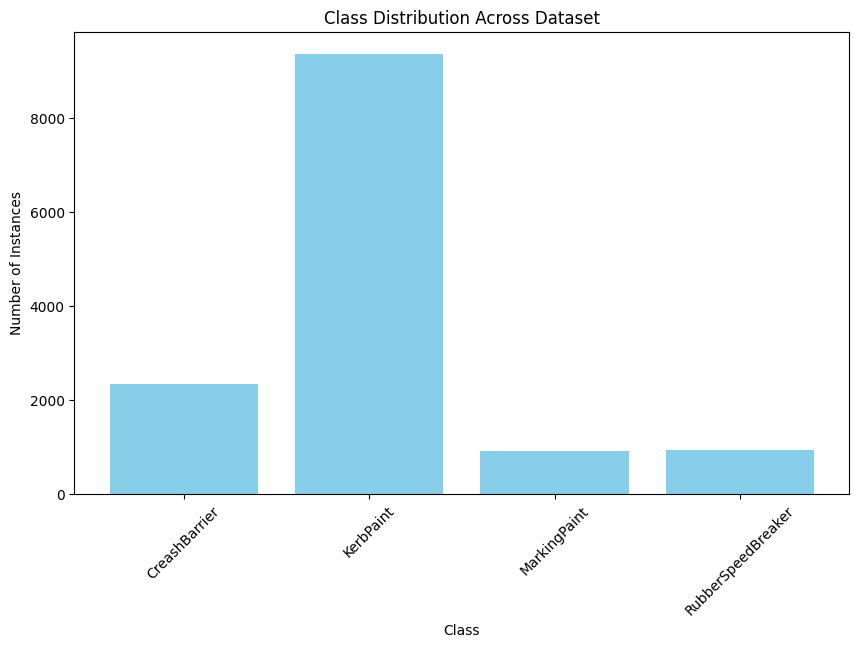


Bounding Box Statistics (in YOLO normalized format):
Average Width: 0.1716 (Std: 0.2493)
Average Height: 0.2176 (Std: 0.2652)


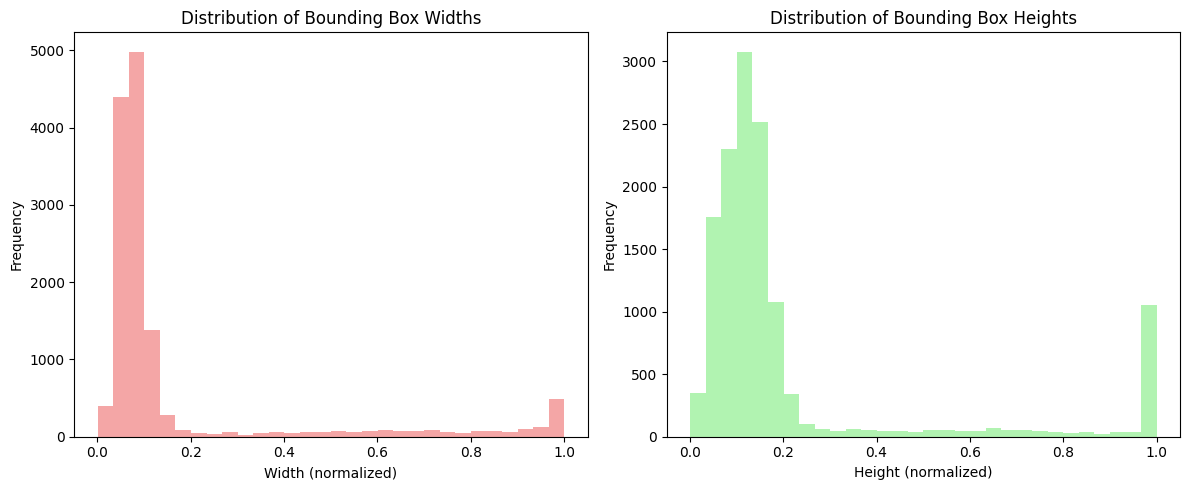


Image Resolution Statistics:
Average Width: 640.0 pixels (Std: 0.0)
Average Height: 640.0 pixels (Std: 0.0)


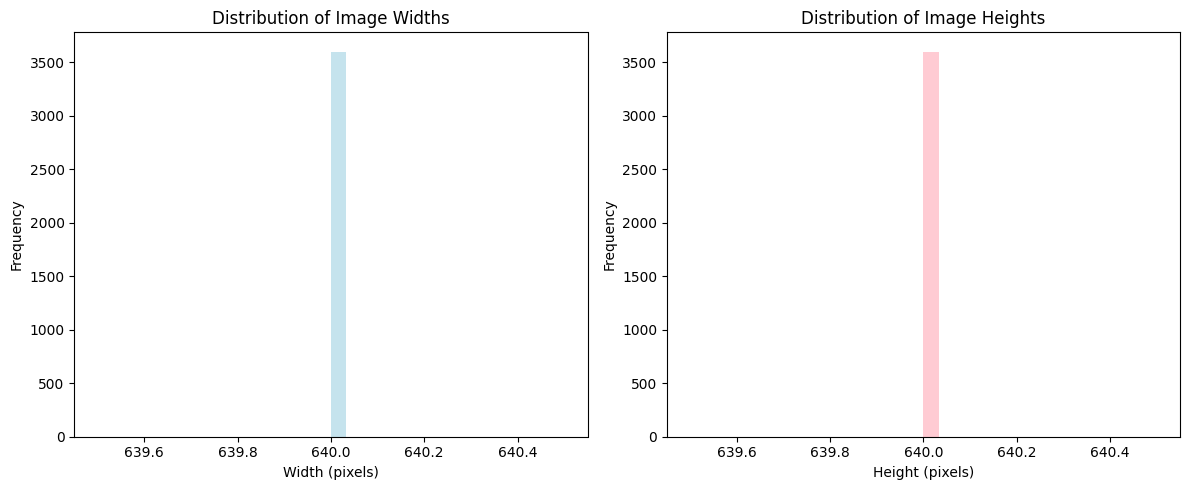


Annotation Count per Image Statistics:
Average Annotations per Image: 3.76 (Std: 4.38)
Min Annotations: 1, Max Annotations: 24


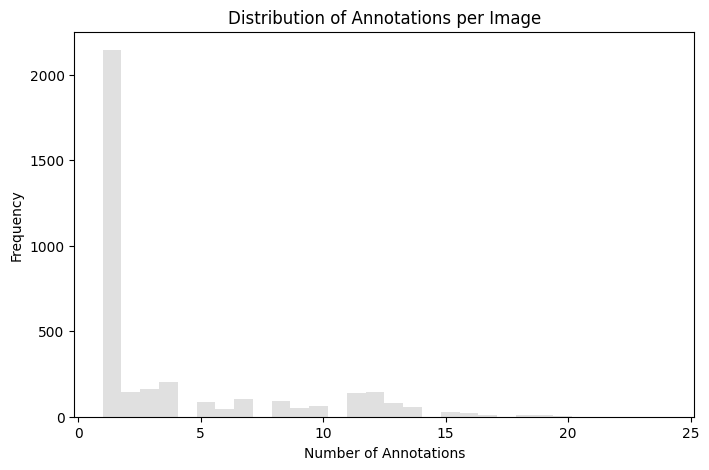

In [ ]:
# Define paths
dataset_path = '/content/drive/MyDrive/Dataset'
splits = ['train', 'val', 'test']

# Step 1: Class distribution
class_counts = defaultdict(int)
annotation_counts = []  # To store the number of annotations per image
bbox_sizes = []  # To store bounding box widths and heights
image_resolutions = []  # To store image resolutions

class_names = ['CreashBarrier', 'KerbPaint', 'MarkingPaint', 'RubberSpeedBreaker']

for split in splits:
    label_dir = os.path.join(dataset_path, 'labels', split)
    image_dir = os.path.join(dataset_path, 'images', split)
    if not os.path.exists(label_dir) or not os.path.exists(image_dir):
        print(f"Directories not found: {label_dir}, {image_dir}")
        continue

    for label_file in os.listdir(label_dir):
        try:
            # Read labels
            with open(os.path.join(label_dir, label_file), 'r') as f:
                labels = [line.strip().split() for line in f.readlines()]

            # Count annotations per image
            annotation_counts.append(len(labels))

            # Update class counts
            for label in labels:
                class_id = int(label[0])
                class_counts[class_id] += 1

                # Extract bounding box sizes (width, height in YOLO format)
                _, _, _, width, height = map(float, label)
                bbox_sizes.append((width, height))

            # Get image resolution
            img_file = label_file.replace('.txt', '.jpg')
            img_path = os.path.join(image_dir, img_file)
            img = cv2.imread(img_path)
            if img is not None:
                h, w = img.shape[:2]
                image_resolutions.append((w, h))
            else:
                print(f"Cannot load image: {img_path}")

        except Exception as e:
            print(f"Error processing {label_file}: {e}")

# Print class distribution
print("\nClass Distribution After Split:")
for class_id, count in sorted(class_counts.items()):
    print(f"{class_names[class_id]}: {count}")

# Plot class distribution as a bar chart
plt.figure(figsize=(10, 6))
plt.bar(class_names, [class_counts[i] for i in range(len(class_names))], color='skyblue')
plt.title("Class Distribution Across Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Instances")
plt.xticks(rotation=45)
plt.show()

# Step 2: Bounding Box Statistics
if bbox_sizes:
    widths, heights = zip(*bbox_sizes)
    print("\nBounding Box Statistics (in YOLO normalized format):")
    print(f"Average Width: {np.mean(widths):.4f} (Std: {np.std(widths):.4f})")
    print(f"Average Height: {np.mean(heights):.4f} (Std: {np.std(heights):.4f})")

    # Plot histogram of bounding box sizes
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(widths, bins=30, color='lightcoral', alpha=0.7)
    plt.title("Distribution of Bounding Box Widths")
    plt.xlabel("Width (normalized)")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    plt.hist(heights, bins=30, color='lightgreen', alpha=0.7)
    plt.title("Distribution of Bounding Box Heights")
    plt.xlabel("Height (normalized)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo bounding box data available for statistics.")

# Step 3: Image Resolution Distribution
if image_resolutions:
    widths, heights = zip(*image_resolutions)
    print("\nImage Resolution Statistics:")
    print(f"Average Width: {np.mean(widths):.1f} pixels (Std: {np.std(widths):.1f})")
    print(f"Average Height: {np.mean(heights):.1f} pixels (Std: {np.std(heights):.1f})")

    # Plot histogram of image resolutions
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(widths, bins=30, color='lightblue', alpha=0.7)
    plt.title("Distribution of Image Widths")
    plt.xlabel("Width (pixels)")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    plt.hist(heights, bins=30, color='lightpink', alpha=0.7)
    plt.title("Distribution of Image Heights")
    plt.xlabel("Height (pixels)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo image resolution data available for statistics.")

# Step 4: Annotation Count per Image
if annotation_counts:
    print("\nAnnotation Count per Image Statistics:")
    print(f"Average Annotations per Image: {np.mean(annotation_counts):.2f} (Std: {np.std(annotation_counts):.2f})")
    print(f"Min Annotations: {np.min(annotation_counts)}, Max Annotations: {np.max(annotation_counts)}")

    # Plot histogram of annotation counts
    plt.figure(figsize=(8, 5))
    plt.hist(annotation_counts, bins=30, color='lightgray', alpha=0.7)
    plt.title("Distribution of Annotations per Image")
    plt.xlabel("Number of Annotations")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("\nNo annotation count data available for statistics.")

# Step 5: Visualize sample images with annotations
def plot_image_with_boxes(img_path, label_path, class_names):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Cannot load image: {img_path}")
        return
    h, w = img.shape[:2]
    try:
        with open(label_path, 'r') as f:
            labels = [line.strip().split() for line in f.readlines()]
    except Exception as e:
        print(f"Error reading label file {label_path}: {e}")
        return

    for label in labels:
        class_id = int(label[0])
        center_x, center_y, width, height = map(float, label[1:])
        x1 = int((center_x - width/2) * w)
        y1 = int((center_y - height/2) * h)
        x2 = int((center_x + width/2) * w)
        y2 = int((center_y + height/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, class_names[class_id], (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [ ]:
# Define paths
dataset_path = '/content/drive/MyDrive/Dataset'
splits = ['train', 'val', 'test']

# Define class names and oversampling factors
class_names = ['CreashBarrier', 'KerbPaint', 'MarkingPaint', 'RubberSpeedBreaker']
oversample_factors = {
    'CreashBarrier': 2,
    'KerbPaint': 1,
    'MarkingPaint': 3,
    'RubberSpeedBreaker': 3
}

# Define updated augmentation pipeline
transform = A.Compose([
    A.Resize(height=640, width=640),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.3),
    A.Blur(blur_limit=3, p=0.3),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2, p=0.3),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Function to clamp bounding box coordinates
def clamp_bbox(bbox):
    center_x, center_y, width, height = bbox
    center_x = max(0.0, min(1.0, center_x))
    center_y = max(0.0, min(1.0, center_y))
    width = max(0.0, min(1.0, width))
    height = max(0.0, min(1.0, height))

    x_max = center_x + width / 2
    y_max = center_y + height / 2
    if x_max > 1.0:
        width = (1.0 - center_x) * 2
    if y_max > 1.0:
        height = (1.0 - center_y) * 2
    if center_x - width / 2 < 0:
        width = center_x * 2
    if center_y - height / 2 < 0:
        height = center_y * 2

    return [center_x, center_y, width, height]

# Preprocess and augment images with oversampling
def preprocess_images(image_dir, label_dir, output_image_dir, output_label_dir):
    os.makedirs(output_image_dir, exist_ok=True)
    os.makedirs(output_label_dir, exist_ok=True)

    processed_count = 0
    image_files = os.listdir(image_dir)

    for img_file in image_files:
        img_path = os.path.join(image_dir, img_file)
        label_path = os.path.join(label_dir, img_file.replace('.jpg', '.txt'))

        # Read image and labels
        img = cv2.imread(img_path)
        if img is None:
            print(f"Skipping corrupted image: {img_file}")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        try:
            with open(label_path, 'r') as f:
                labels = [line.strip().split() for line in f.readlines()]
        except Exception as e:
            print(f"Error reading label file {label_path}: {e}")
            continue

        if not labels:
            print(f"No annotations for {img_file}, copying without augmentation.")
            cv2.imwrite(os.path.join(output_image_dir, img_file), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
            shutil.copy(label_path, os.path.join(output_label_dir, img_file.replace('.jpg', '.txt')))
            processed_count += 1
            continue

        class_labels = [int(label[0]) for label in labels]
        bboxes = [list(map(float, label[1:])) for label in labels]

        # Clamp bounding box coordinates
        bboxes = [clamp_bbox(bbox) for bbox in bboxes]

        # Determine oversampling factor based on the classes present
        max_factor = 1
        for class_id in class_labels:
            class_name = class_names[class_id]
            factor = oversample_factors[class_name]
            max_factor = max(max_factor, factor)

        # Apply augmentations for each oversampled instance
        for i in range(max_factor):
            try:
                augmented = transform(image=img, bboxes=bboxes, class_labels=class_labels)
                aug_img = augmented['image']
                aug_bboxes = augmented['bboxes']
                aug_labels = augmented['class_labels']
            except Exception as e:
                print(f"Error augmenting {img_file} (iteration {i+1}): {e}")
                continue

            # Save augmented image
            if i == 0:
                aug_img_file = img_file
            else:
                base, ext = os.path.splitext(img_file)
                aug_img_file = f"{base}_aug_{i}{ext}"

            aug_img = cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR)
            cv2.imwrite(os.path.join(output_image_dir, aug_img_file), aug_img)

            # Save updated labels
            label_file = aug_img_file.replace('.jpg', '.txt')
            with open(os.path.join(output_label_dir, label_file), 'w') as f:
                for class_id, bbox in zip(aug_labels, aug_bboxes):
                    f.write(f"{class_id} {' '.join(map(str, bbox))}\n")

            processed_count += 1

    print(f"Processed {processed_count} images in {image_dir}")

# Preprocess all splits
for split in splits:
    print(f"\nPreprocessing {split} split...")
    image_dir = os.path.join(dataset_path, 'images', split)
    label_dir = os.path.join(dataset_path, 'labels', split)
    if not os.path.exists(image_dir) or not os.path.exists(label_dir):
        print(f"Directories not found: {image_dir}, {label_dir}")
        continue
    preprocess_images(
        image_dir,
        label_dir,
        image_dir,
        label_dir
    )

print("\nPreprocessing completed.")


Preprocessing train split...
Processed 6506 images in /content/drive/MyDrive/Dataset/images/train

Preprocessing val split...
Processed 807 images in /content/drive/MyDrive/Dataset/images/val

Preprocessing test split...
Processed 787 images in /content/drive/MyDrive/Dataset/images/test

Preprocessing completed.


In [ ]:
import os
from ultralytics import YOLO

# Define paths
dataset_path = '/content/drive/MyDrive/Dataset'
data_yaml = os.path.join(dataset_path, 'data.yaml')

# Load the YOLOv8m model
model = YOLO('yolov8m.pt')

# Train the model with updated epochs
results = model.train(
    data=data_yaml,
    epochs=10,  # Updated from 20 to 10
    imgsz=640,
    batch=16,
    name='yolov8m_exp',
    project='/content/drive/MyDrive/Dataset/runs',
    device=0,
    patience=50,
    save=True,
    val=True,
    exist_ok=True,
    cls=1.0,
)

# Evaluate the model on the test set
metrics = model.val(split='test')

# Print evaluation metrics
print("\nEvaluation Metrics on Test Set:")
print(f"mAP@50: {metrics.box.map50:.4f}")
print(f"mAP@50:95: {metrics.box.map:.4f}")
print("Per-class AP@50:")
for i, ap in enumerate(metrics.box.maps):
    print(f"{model.names[i]}: {ap:.4f}")

# Save the trained model
model.save('/content/drive/MyDrive/Dataset/yolov8m_final.pt')

print("Training and evaluation completed.")


100%|██████████| 49.7M/49.7M [00:00<00:00, 126MB/s]


Ultralytics 8.3.137 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.0, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8m_exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.

100%|██████████| 5.35M/5.35M [00:00<00:00, 96.8MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 1.7±3.2 ms, read: 83.8±91.4 MB/s, size: 150.6 KB)


train: Scanning /content/drive/MyDrive/Dataset/labels/train... 6506 images, 3 backgrounds, 0 corrupt: 100%|██████████| 6506/6506 [01:50<00:00, 58.85it/s] 


...

                   all        807       1963      0.623       0.39      0.394      0.212
         CreashBarrier        197        535      0.391      0.129      0.128     0.0585
             KerbPaint         87        906          1          0     0.0674     0.0239
          MarkingPaint        264        264      0.497       0.58      0.556      0.299
    RubberSpeedBreaker        258        258      0.603      0.853      0.825      0.468
Speed: 0.2ms preprocess, 9.4ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to /content/drive/MyDrive/Dataset/runs/yolov8m_exp
Ultralytics 8.3.137 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 30.9±28.3 MB/s, size: 189.0 KB)


val: Scanning /content/drive/MyDrive/Dataset/labels/test... 787 images, 0 backgrounds, 0 corrupt: 100%|██████████| 787/787 [00:09<00:00, 82.38it/s] 


val: New cache created: /content/drive/MyDrive/Dataset/labels/test.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:22<00:00,  2.26it/s]


                   all        787       1942      0.602      0.424      0.387      0.218
         CreashBarrier        210        519       0.36      0.121      0.114     0.0452
             KerbPaint         94        937          1          0     0.0851     0.0292
          MarkingPaint        231        231      0.524      0.724      0.605      0.352
    RubberSpeedBreaker        252        255      0.524      0.851      0.746      0.444
Speed: 0.7ms preprocess, 21.2ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/drive/MyDrive/Dataset/runs/yolov8m_exp

Evaluation Metrics on Test Set:
mAP@50: 0.3874
mAP@50:95: 0.2177
Per-class AP@50:
CreashBarrier: 0.0452
KerbPaint: 0.0292
MarkingPaint: 0.3522
RubberSpeedBreaker: 0.4441
Training and evaluation completed.


In [ ]:
import os
from ultralytics import YOLO

# Define paths
dataset_path = '/content/drive/MyDrive/Dataset'
data_yaml = os.path.join(dataset_path, 'data.yaml')

# Load the YOLOv8s model (changed from yolov8m.pt)
model = YOLO('yolov8s.pt')

# Train the model for 10 epochs
results = model.train(
    data=data_yaml,
    epochs=10,
    imgsz=640,
    batch=16,
    name='yolov8s_exp',
    project='/content/drive/MyDrive/Dataset/runs',
    device=0,
    patience=50,
    save=True,
    val=True,
    exist_ok=True,
    cls=1.0,
)

# Evaluate the model on the test set
metrics = model.val(split='test')

# Print evaluation metrics
print("\nEvaluation Metrics on Test Set:")
print(f"mAP@50: {metrics.box.map50:.4f}")
print(f"mAP@50:95: {metrics.box.map:.4f}")
print("Per-class AP@50:")
for i, ap in enumerate(metrics.box.maps):
    print(f"{model.names[i]}: {ap:.4f}")

# Save the trained model
model.save('/content/drive/MyDrive/Dataset/yolov8s_final.pt')

print("Training and evaluation completed.")


100%|██████████| 21.5M/21.5M [00:00<00:00, 241MB/s]


Ultralytics 8.3.137 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.0, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8s_exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.

train: Scanning /content/drive/MyDrive/Dataset/labels/train.cache... 6506 images, 3 backgrounds, 0 corrupt: 100%|██████████| 6506/6506 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 7.1±14.7 ms, read: 64.3±82.3 MB/s, size: 219.3 KB)


...


10 epochs completed in 0.449 hours.
Optimizer stripped from /content/drive/MyDrive/Dataset/runs/yolov8s_exp/weights/last.pt, 22.5MB
Optimizer stripped from /content/drive/MyDrive/Dataset/runs/yolov8s_exp/weights/best.pt, 22.5MB

Validating /content/drive/MyDrive/Dataset/runs/yolov8s_exp/weights/best.pt...
Ultralytics 8.3.137 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:16<00:00,  1.59it/s]


                   all        807       1963      0.664      0.377      0.391       0.22
         CreashBarrier        197        535      0.459      0.118      0.137     0.0611
             KerbPaint         87        906          1          0     0.0696     0.0233
          MarkingPaint        264        264      0.547      0.561      0.538      0.307
    RubberSpeedBreaker        258        258      0.649       0.83      0.822      0.486
Speed: 0.4ms preprocess, 4.5ms inference, 0.0ms loss, 5.2ms postprocess per image
Results saved to /content/drive/MyDrive/Dataset/runs/yolov8s_exp
Ultralytics 8.3.137 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 54.9±58.1 MB/s, size: 189.0 KB)


val: Scanning /content/drive/MyDrive/Dataset/labels/test.cache... 787 images, 0 backgrounds, 0 corrupt: 100%|██████████| 787/787 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:17<00:00,  2.85it/s]


                   all        787       1942      0.649      0.405      0.407      0.231
         CreashBarrier        210        519      0.453      0.143      0.144      0.058
             KerbPaint         94        937          1          0     0.0882     0.0311
          MarkingPaint        231        231      0.537      0.641      0.578      0.356
    RubberSpeedBreaker        252        255      0.604      0.835      0.817      0.478
Speed: 1.2ms preprocess, 9.3ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/drive/MyDrive/Dataset/runs/yolov8s_exp

Evaluation Metrics on Test Set:
mAP@50: 0.4068
mAP@50:95: 0.2308
Per-class AP@50:
CreashBarrier: 0.0580
KerbPaint: 0.0311
MarkingPaint: 0.3564
RubberSpeedBreaker: 0.4776
Training and evaluation completed.
